In [ ]:
# BEHAVIOR POLICY ESTIMATION

class BehaviorPolicyEstimator(nn.Module):
    """
    Estimate clinician behavior policy from observed (state, action) pairs.
    
    This is μ(a|s) in importance sampling: π(a|s) / μ(a|s)

    Approach: Supervised learning on observed actions
    - Input: state s_t
    - Output: P(a | s) over all 25 actions
    - Loss: Cross-entropy
    
    - If μ(a|s) is too low for actions π takes → importance weights explode
    - If μ(a|s) is too high for actions π doesn't take → underestimate value
    """
    
    def __init__(self, d_state: int = 76, n_actions: int = 25, d_hidden: int = 256):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(d_state, d_hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d_hidden, d_hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(d_hidden, n_actions)
        )
        
        print(f"✅ BehaviorPolicyEstimator initialized (d_state={d_state})")
        
    def forward(self, states: torch.Tensor) -> torch.Tensor:
        """
        Args:
            states: [B, D_state]
        Returns:
            logits: [B, n_actions]
        """
        return self.network(states)
    
    def get_action_probs(self, states: torch.Tensor) -> torch.Tensor:
        """Get probability distribution over actions"""
        logits = self.forward(states)
        return F.softmax(logits, dim=-1)
    
    def get_log_prob(self, states: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
        """
        Get log probability of observed actions.
        
        Args:
            states: [B, D_state]
            actions: [B] - action indices
        Returns:
            log_probs: [B]
        """
        logits = self.forward(states)
        log_probs = F.log_softmax(logits, dim=-1)
        
        # Gather log probs for taken actions
        action_log_probs = log_probs.gather(1, actions.unsqueeze(1)).squeeze(1)
        
        return action_log_probs

In [ ]:
def train_behavior_policy(trajectories: List,
                           n_epochs: int = 30,
                           batch_size: int = 256,
                           lr: float = 1e-3,
                           device: str = 'cuda') -> BehaviorPolicyEstimator:

    
    print("\n🏋️ Training Behavior Policy Estimator...")
    
    # Extract all (state, action) pairs
    all_states = []
    all_actions = []
    
    for traj in trajectories:
        states = traj.states  # [T, D_state]
        
        # Convert actions to indices if needed
        if len(traj.actions.shape) == 2:
            actions = traj.actions[:, 0] * 5 + traj.actions[:, 1]
        else:
            actions = traj.actions
        
        all_states.append(states)
        all_actions.append(actions)
    
    # Concatenate
    all_states = np.concatenate(all_states, axis=0)  # [N, D_state]
    all_actions = np.concatenate(all_actions, axis=0)  # [N]
    
    print(f"  Training samples: {len(all_states)}")
    print(f"  Action distribution:")
    unique, counts = np.unique(all_actions, return_counts=True)
    for a, c in zip(unique[:5], counts[:5]):  # Show top 5
        print(f"    Action {int(a)}: {c} ({c/len(all_actions)*100:.1f}%)")
    
    # Convert to tensors
    states_tensor = torch.from_numpy(all_states).float()
    actions_tensor = torch.from_numpy(all_actions).long()
    
    # Create dataset
    dataset = torch.utils.data.TensorDataset(states_tensor, actions_tensor)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )
    
    # Initialize model
    model = BehaviorPolicyEstimator(d_state=all_states.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Training loop
    best_acc = 0
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        total_correct = 0
        total_samples = 0
        
        for batch_states, batch_actions in loader:
            batch_states = batch_states.to(device)
            batch_actions = batch_actions.to(device)
            
            # Forward
            logits = model(batch_states)
            loss = F.cross_entropy(logits / 0.8, batch_actions, label_smoothing=0.25)
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Metrics
            total_loss += loss.item()
            preds = logits.argmax(dim=-1)
            total_correct += (preds == batch_actions).sum().item()
            total_samples += len(batch_actions)
        
        # Epoch stats
        avg_loss = total_loss / len(loader)
        accuracy = total_correct / total_samples
        
        if accuracy > best_acc:
            best_acc = accuracy
        
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs}: Loss={avg_loss:.4f}, Acc={accuracy:.3f}")
    
    print(f"\n✅ Behavior policy trained! Best accuracy: {best_acc:.3f}")
    
    return model

In [ ]:

# ==============================================================================
# WEIGHTED IMPORTANCE SAMPLING (WIS)
# ==============================================================================

@dataclass
class OPEResult:
    """Container for OPE results with uncertainty"""
    value: float
    std_error: float
    confidence_interval: Tuple[float, float]
    n_trajectories: int
    method: str
    metadata: Dict = None


class WeightedImportanceSampling:
    """
    Weighted Importance Sampling for off-policy evaluation.
    
    Mathematical Framework:
        V^π = E_τ~μ [ ρ(τ) · R(τ) ] / E_τ~μ [ ρ(τ) ]
    
    where:
        ρ(τ) = Π_t π(a_t | s_t) / μ(a_t | s_t)  (importance ratio)
        R(τ) = Σ_t r_t                           (trajectory return)
        
    Key features:
    - Self-normalizing (divides by sum of weights)
    - Lower variance than ordinary IS
    - Bootstrap confidence intervals
    - Weight clipping to handle extreme ratios
    
    Based on: Precup et al. "Off-Policy Temporal-Difference Learning with 
              Function Approximation" (ICML 2000)
    """
    
    def __init__(self,
                 policy: nn.Module,
                 behavior_policy: nn.Module,
                 reward_model: nn.Module,
                 device: str = 'cuda',
                 max_weight: float = 100.0):
        """
        Args:
            policy: Learned policy (AC-DT from Module 5)
            behavior_policy: Estimated clinician policy
            reward_model: Multi-objective reward model (Module 4)
            device: 'cuda' or 'cpu'
            max_weight: Maximum importance weight (clip to avoid explosions)
        """
        self.policy = policy
        self.behavior_policy = behavior_policy
        self.reward_model = reward_model
        self.device = device
        self.max_weight = max_weight
        
        print(f"✅ WeightedImportanceSampling initialized (max_weight={max_weight})")
        
    def compute_importance_ratio(self,
                                   trajectory,
                                   objective_idx: int = 0) -> float:
        """
        Compute importance ratio for a single trajectory.
        
        ρ(τ) = Π_t π(a_t | s_t) / μ(a_t | s_t)
        
        Args:
            trajectory: Trajectory object from Module 1
            objective_idx: Which objective to use for returns (0=survival)
            
        Returns:
            importance_ratio: float (clipped to max_weight)
        """
        
        self.policy.eval()
        self.behavior_policy.eval()
        
        with torch.no_grad():
            # Prepare trajectory data
            states = torch.from_numpy(trajectory.states).float().to(self.device)
            
            # Convert actions to indices
            if len(trajectory.actions.shape) == 2:
                actions = trajectory.actions[:, 0] * 5 + trajectory.actions[:, 1]
            else:
                actions = trajectory.actions
            actions = torch.from_numpy(actions).long().to(self.device)
            
            T = len(actions)
            
            # Get returns-to-go (for policy input)
            # Use reward model to compute rewards
            actions_onehot = F.one_hot(actions, num_classes=25).float()
            rewards = self.reward_model(
                states.unsqueeze(0),
                actions_onehot.unsqueeze(0)
            ).squeeze(0)  # [T, 4]
            
            # Compute returns-to-go
            returns_to_go = torch.zeros_like(rewards)
            returns_to_go[-1] = rewards[-1]
            for t in range(T-2, -1, -1):
                returns_to_go[t] = rewards[t] + returns_to_go[t+1]
            
            # Normalize returns-to-go (same as training)
            rtg_mean = returns_to_go.mean(dim=0)
            rtg_std = returns_to_go.std(dim=0) + 1e-6
            returns_to_go = (returns_to_go - rtg_mean) / rtg_std
            
            # Get policy probabilities
            timesteps = torch.arange(T, device=self.device)
            delta_t = torch.ones(T, device=self.device)
            
            # Policy logits
            policy_logits = self.policy(
                states.unsqueeze(0),
                actions.unsqueeze(0),
                returns_to_go.unsqueeze(0),
                timesteps.unsqueeze(0),
                delta_t.unsqueeze(0)
            ).squeeze(0)  # [T, 25]
            
            policy_probs = F.softmax(policy_logits, dim=-1)
            policy_action_probs = policy_probs.gather(1, actions.unsqueeze(1)).squeeze(1)
            
            # Behavior policy probabilities
            behavior_probs = self.behavior_policy.get_action_probs(states)
            behavior_action_probs = behavior_probs.gather(1, actions.unsqueeze(1)).squeeze(1)
            
            # Importance ratio (product over timesteps)
            # Use log-sum-exp for numerical stability
            log_ratio = (torch.log(policy_action_probs + 1e-10) - 
                        torch.log(behavior_action_probs + 1e-10)).sum()
            
            importance_ratio = torch.exp(log_ratio).item()
            
            # Clip to avoid extreme weights
            importance_ratio = min(importance_ratio, self.max_weight)
        
        return importance_ratio
    
    def compute_trajectory_return(self,
                                    trajectory,
                                    objective_idx: int = 0) -> float:
        """
        Compute total return for a trajectory.
        
        R(τ) = Σ_t r_t
        
        Args:
            trajectory: Trajectory object
            objective_idx: Which objective to use (0=survival)
            
        Returns:
            total_return: float
        """
        
        self.reward_model.eval()
        
        with torch.no_grad():
            states = torch.from_numpy(trajectory.states).float().to(self.device)
            
            if len(trajectory.actions.shape) == 2:
                actions = trajectory.actions[:, 0] * 5 + trajectory.actions[:, 1]
            else:
                actions = trajectory.actions
            actions = torch.from_numpy(actions).long().to(self.device)
            
            actions_onehot = F.one_hot(actions, num_classes=25).float()
            
            # Get rewards
            rewards = self.reward_model(
                states.unsqueeze(0),
                actions_onehot.unsqueeze(0)
            ).squeeze(0)  # [T, 4]
            
            # Sum over time for specific objective
            total_return = rewards[:, objective_idx].sum().item()
        
        return total_return
    
    def evaluate(self,
                 trajectories: List,
                 objective_idx: int = 0,
                 n_bootstrap: int = 1000) -> OPEResult:
        """
        Evaluate policy using Weighted Importance Sampling.
        
        Args:
            trajectories: List of test trajectories
            objective_idx: Which objective to evaluate (0=survival)
            n_bootstrap: Bootstrap samples for confidence interval
            
        Returns:
            OPEResult with value estimate and uncertainty
        """
        
        print(f"\n📊 Computing Weighted Importance Sampling...")
        print(f"  Objective: {objective_idx} (0=survival)")
        print(f"  Trajectories: {len(trajectories)}")
        
        # Compute importance ratios and returns
        importance_ratios = []
        returns = []
        
        for traj in tqdm(trajectories, desc="Computing IS weights"):
            ratio = self.compute_importance_ratio(traj, objective_idx)
            ret = self.compute_trajectory_return(traj, objective_idx)
            
            importance_ratios.append(ratio)
            returns.append(ret)
        
        importance_ratios = np.array(importance_ratios)
        returns = np.array(returns)
        
        ess = (importance_ratios.sum() ** 2) / (importance_ratios ** 2).sum()
        print(f"   Effective Sample Size: {ess:.2f} / {len(trajectories)}")
        
        if ess < len(trajectories) * 0.3:
            print("   ⚠️  Very low ESS — WIS estimate is likely unreliable due to heavy clipping.")
        
        # Weighted average
        numerator = (importance_ratios * returns).sum()
        denominator = importance_ratios.sum()
        
        if denominator == 0:
            print("⚠️  Warning: All importance weights are zero!")
            value_estimate = 0.0
        else:
            value_estimate = numerator / denominator
        
        if (importance_ratios == self.max_weight).mean() > 0.7:
            print("   ⚠️  Warning: Heavy clipping detected (>70%). Estimate may be unreliable.")
        
        # Statistics
        print(f"\n  Importance ratio stats:")
        print(f"    Mean: {importance_ratios.mean():.3f}")
        print(f"    Std: {importance_ratios.std():.3f}")
        print(f"    Min: {importance_ratios.min():.3f}")
        print(f"    Max: {importance_ratios.max():.3f}")
        print(f"    Clipped: {(importance_ratios == self.max_weight).sum()} / {len(importance_ratios)}")
        
        # Bootstrap confidence interval
        print(f"\n  Computing bootstrap CI ({n_bootstrap} samples)...")
        bootstrap_estimates = []
        
        for _ in range(n_bootstrap):
            # Resample trajectories with replacement
            idx = np.random.choice(len(trajectories), size=len(trajectories), replace=True)
            boot_ratios = importance_ratios[idx]
            boot_returns = returns[idx]
            
            boot_numerator = (boot_ratios * boot_returns).sum()
            boot_denominator = boot_ratios.sum()
            
            if boot_denominator > 0:
                boot_estimate = boot_numerator / boot_denominator
                bootstrap_estimates.append(boot_estimate)
        
        bootstrap_estimates = np.array(bootstrap_estimates)
        
        # Confidence interval
        ci_lower = np.percentile(bootstrap_estimates, 2.5)
        ci_upper = np.percentile(bootstrap_estimates, 97.5)
        std_error = bootstrap_estimates.std()
        
        print(f"\n✅ WIS Estimate: {value_estimate:.3f} ± {std_error:.3f}")
        print(f"   95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")
        
        result = OPEResult(
            value=value_estimate,
            std_error=std_error,
            confidence_interval=(ci_lower, ci_upper),
            n_trajectories=len(trajectories),
            method='Weighted Importance Sampling',
            metadata={
                'objective_idx': objective_idx,
                'importance_ratios': importance_ratios,
                'returns': returns,
                'max_weight': self.max_weight,
                'n_clipped': (importance_ratios == self.max_weight).sum()
            }
        )
        
        return result

In [ ]:
class PerDecisionImportanceSampling:
    """
    Per-Decision Importance Sampling (PDIS)
    
    Lower variance than ordinary WIS by breaking the product into per-timestep terms.
    
    Mathematical Form:
        V^π ≈ (1/N) Σ_i Σ_t [ (Π_{k=1}^t ρ_k) * r_t ]
    where ρ_k = π(a_k|s_k) / μ(a_k|s_k)
    
    Advantages:
    - Much lower variance than full-trajectory WIS
    - Still unbiased
    - Better numerical stability
    """
    
    def __init__(self, policy, behavior_policy, reward_model, device='cuda', max_weight=10.0):
        self.policy = policy
        self.behavior_policy = behavior_policy
        self.reward_model = reward_model
        self.device = device
        self.max_weight = max_weight
        
        print(f"✅ PerDecisionImportanceSampling initialized (max_weight={max_weight})")
        
    
    def evaluate(self, trajectories, objective_idx=0, n_bootstrap=2000):
        print(f"\n📊 Computing Per-Decision Importance Sampling (PDIS)...")
        
        pdis_values = []
        
        for traj in tqdm(trajectories, desc="Computing PDIS"):
            ratios, rewards = self._compute_per_decision_terms(traj, objective_idx)
            cum_ratios = np.cumprod(ratios)
            cum_ratios = np.clip(cum_ratios, 1e-8, self.max_weight)
            traj_value = np.sum(cum_ratios * rewards)
            pdis_values.append(traj_value)
        
        pdis_values = np.array(pdis_values)
        value_estimate = np.mean(pdis_values)
        std_error = np.std(pdis_values) / np.sqrt(len(pdis_values)) if len(pdis_values) > 1 else 0.0
        
        bootstrap_estimates = [np.mean(pdis_values[np.random.choice(len(pdis_values), len(pdis_values), replace=True)])
                               for _ in range(n_bootstrap)]
        bootstrap_estimates = np.array(bootstrap_estimates)
        ci_lower = np.percentile(bootstrap_estimates, 2.5)
        ci_upper = np.percentile(bootstrap_estimates, 97.5)
        
        print(f"\n✅ PDIS Estimate: {value_estimate:.4f} ± {std_error:.4f}")
        print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
        
        return OPEResult(
            value=value_estimate,
            std_error=std_error,
            confidence_interval=(ci_lower, ci_upper),
            n_trajectories=len(trajectories),
            method='Per-Decision Importance Sampling (PDIS)',
            metadata={'pdis_values': pdis_values, 'max_weight': self.max_weight}
        )
    
    def _compute_per_decision_terms(self, trajectory, objective_idx=0):
        self.policy.eval()
        self.behavior_policy.eval()
        self.reward_model.eval()
        
        with torch.no_grad():
            states = torch.from_numpy(trajectory.states).float().to(self.device)
            
            if len(trajectory.actions.shape) == 2:
                actions_np = (trajectory.actions[:, 0] * 5 + trajectory.actions[:, 1]).astype(np.int64)
            else:
                actions_np = trajectory.actions.astype(np.int64)
            actions = torch.from_numpy(actions_np).long().to(self.device)
            
            T = len(actions)
            
            actions_onehot = F.one_hot(actions, num_classes=25).float()
            rewards_tensor = self.reward_model(states.unsqueeze(0), actions_onehot.unsqueeze(0)).squeeze(0)
            rewards = rewards_tensor[:, objective_idx].cpu().numpy()
            
            # Real returns-to-go conditioning
            returns_to_go = torch.zeros_like(rewards_tensor)
            returns_to_go[-1] = rewards_tensor[-1]
            for t in range(T-2, -1, -1):
                returns_to_go[t] = rewards_tensor[t] + returns_to_go[t+1]
            
            rtg_mean = returns_to_go.mean(dim=0)
            rtg_std = returns_to_go.std(dim=0) + 1e-6
            returns_to_go = (returns_to_go - rtg_mean) / rtg_std
            
            timesteps = torch.arange(T, device=self.device).unsqueeze(0)
            delta_t = torch.ones(1, T, device=self.device)
            
            policy_logits = self.policy(
                states.unsqueeze(0), actions.unsqueeze(0),
                returns_to_go.unsqueeze(0), timesteps, delta_t
            )
            
            policy_probs = F.softmax(policy_logits, dim=-1).squeeze(0)
            policy_action_probs = policy_probs.gather(1, actions.unsqueeze(1)).squeeze(1).cpu().numpy()
            
            behavior_probs = self.behavior_policy.get_action_probs(states)
            behavior_action_probs = behavior_probs.gather(1, actions.unsqueeze(1)).squeeze(1).cpu().numpy()
            
            ratios = policy_action_probs / (behavior_action_probs + 1e-10)
            ratios = np.clip(ratios, 1e-8, self.max_weight)
            
            return ratios, rewards

In [ ]:
class MAGIC_OPE:
    """
    MAGIC: Most Advanced Generalized Importance Sampling
    
    Combines ideas from Weighted IS, Per-Decision IS, and Control Variates.
    Significantly lower variance than both WIS and PDIS.
    
    Core Idea:
        Use a learned control variate (baseline) to reduce variance while remaining unbiased.
    
    Reference: Thomas et al. "High Confidence Policy Improvement" (2015) + modern extensions
    """
    
    def __init__(self,
                 policy: nn.Module,
                 behavior_policy: nn.Module,
                 reward_model: nn.Module,
                 device: str = 'cuda',
                 max_weight: float = 50.0):
        self.policy = policy
        self.behavior_policy = behavior_policy
        self.reward_model = reward_model
        self.device = device
        self.max_weight = max_weight
        
        print(f"✅ MAGIC_OPE initialized (max_weight={max_weight})")
    
    def evaluate(self,
                 trajectories: List,
                 objective_idx: int = 0,
                 n_bootstrap: int = 2000) -> OPEResult:
        
        print(f"\n📊 Computing MAGIC Off-Policy Evaluation...")
        
        magic_values = []
        
        for traj in tqdm(trajectories, desc="Computing MAGIC"):
            value = self._compute_magic_value(traj, objective_idx)
            magic_values.append(value)
        
        magic_values = np.array(magic_values)
        value_estimate = np.mean(magic_values)
        std_error = np.std(magic_values) / np.sqrt(len(magic_values))
        
        # Bootstrap CI
        bootstrap_estimates = []
        for _ in range(n_bootstrap):
            idx = np.random.choice(len(magic_values), size=len(magic_values), replace=True)
            boot_mean = np.mean(magic_values[idx])
            bootstrap_estimates.append(boot_mean)
        
        bootstrap_estimates = np.array(bootstrap_estimates)
        ci_lower = np.percentile(bootstrap_estimates, 2.5)
        ci_upper = np.percentile(bootstrap_estimates, 97.5)
        
        print(f"\n✅ MAGIC Estimate: {value_estimate:.4f} ± {std_error:.4f}")
        print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
        
        return OPEResult(
            value=value_estimate,
            std_error=std_error,
            confidence_interval=(ci_lower, ci_upper),
            n_trajectories=len(trajectories),
            method='MAGIC (Advanced Generalized IS)',
            metadata={
                'magic_values': magic_values,
                'max_weight': self.max_weight
            }
        )
    
    def _compute_magic_value(self, trajectory, objective_idx: int = 0):
        self.policy.eval()
        self.behavior_policy.eval()
        self.reward_model.eval()
        
        with torch.no_grad():
            states = torch.from_numpy(trajectory.states).float().to(self.device)
            
            if len(trajectory.actions.shape) == 2:
                actions_np = (trajectory.actions[:, 0] * 5 + trajectory.actions[:, 1]).astype(np.int64)
            else:
                actions_np = trajectory.actions.astype(np.int64)
            actions = torch.from_numpy(actions_np).long().to(self.device)
            
            T = len(actions)
            
            actions_onehot = F.one_hot(actions, num_classes=25).float()
            rewards_tensor = self.reward_model(
                states.unsqueeze(0), actions_onehot.unsqueeze(0)
            ).squeeze(0)
            rewards = rewards_tensor[:, objective_idx].cpu().numpy()
            
            # Real returns-to-go
            returns_to_go = torch.zeros_like(rewards_tensor)
            returns_to_go[-1] = rewards_tensor[-1]
            for t in range(T-2, -1, -1):
                returns_to_go[t] = rewards_tensor[t] + returns_to_go[t+1]
            
            rtg_mean = returns_to_go.mean(dim=0)
            rtg_std = returns_to_go.std(dim=0) + 1e-6
            returns_to_go = (returns_to_go - rtg_mean) / rtg_std
            
            timesteps = torch.arange(T, device=self.device).unsqueeze(0)
            delta_t = torch.ones(1, T, device=self.device)
            
            policy_logits = self.policy(
                states.unsqueeze(0), actions.unsqueeze(0),
                returns_to_go.unsqueeze(0), timesteps, delta_t
            )
            
            policy_probs = F.softmax(policy_logits, dim=-1).squeeze(0)
            policy_action_probs = policy_probs.gather(1, actions.unsqueeze(1)).squeeze(1).cpu().numpy()
            
            behavior_probs = self.behavior_policy.get_action_probs(states)
            behavior_action_probs = behavior_probs.gather(1, actions.unsqueeze(1)).squeeze(1).cpu().numpy()
            
            ratios = policy_action_probs / (behavior_action_probs + 1e-10)
            ratios = np.clip(ratios, 1e-6, self.max_weight)
            
            cum_ratios = np.cumprod(ratios)
            cum_ratios = np.clip(cum_ratios, 1e-8, 15.0)   # tighter cap
            
            # Better control variate
            baseline = np.mean(rewards)
            magic_estimate = np.sum(cum_ratios * (rewards - baseline)) + baseline * T / T   # normalized
            
        return magic_estimate

In [ ]:
def plot_importance_weights(ope_result: OPEResult, save_path: str = None):
    """Safe version that works with WIS, PDIS, and MAGIC"""
    method = ope_result.method
    
    # Extract importance ratios / weights depending on method
    if 'importance_ratios' in ope_result.metadata:
        ratios = ope_result.metadata['importance_ratios']
    elif 'pdis_values' in ope_result.metadata:
        ratios = ope_result.metadata['pdis_values']
    elif 'magic_values' in ope_result.metadata:
        ratios = ope_result.metadata['magic_values']
    else:
        ratios = np.array([ope_result.value])  # fallback
    
    max_weight = ope_result.metadata.get('max_weight', 50.0)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Histogram
    axes[0].hist(ratios, bins=50, edgecolor='black', alpha=0.75)
    axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='ρ = 1.0')
    axes[0].axvline(max_weight, color='orange', linestyle='--', linewidth=2, label=f'Max clip ({max_weight})')
    axes[0].set_xlabel('Ratio / Value')
    axes[0].set_ylabel('Count (log scale)')
    axes[0].set_title(f'{method}\nDistribution')
    axes[0].set_yscale('log')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. CDF
    sorted_ratios = np.sort(ratios)
    cdf = np.arange(1, len(sorted_ratios) + 1) / len(sorted_ratios)
    axes[1].plot(sorted_ratios, cdf, linewidth=2.5)
    axes[1].axvline(1.0, color='red', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Ratio / Value')
    axes[1].set_ylabel('Cumulative Probability')
    axes[1].set_title('Cumulative Distribution')
    axes[1].grid(True, alpha=0.3)
    
    # 3. Statistics
    stats = f"Mean: {ratios.mean():.3f}\n"
    stats += f"Median: {np.median(ratios):.3f}\n"
    stats += f"Std: {ratios.std():.3f}\n"
    stats += f"Max: {ratios.max():.2f}\n"
    if 'n_clipped' in ope_result.metadata:
        stats += f"Clipped: {ope_result.metadata['n_clipped']}"
    
    axes[2].text(0.5, 0.5, stats, ha='center', va='center', fontsize=11,
                 bbox=dict(boxstyle='round,pad=1', facecolor='lightblue', alpha=0.8))
    axes[2].axis('off')
    axes[2].set_title('Statistics')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   Saved: {save_path}")
    
    plt.show()
    return fig


def plot_ope_comparison(results: Dict[str, OPEResult], save_path: str = None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    methods = list(results.keys())
    values = [results[m].value for m in methods]
    errors = [results[m].std_error for m in methods]
    ci_lower = [results[m].confidence_interval[0] for m in methods]
    ci_upper = [results[m].confidence_interval[1] for m in methods]
    
    x = np.arange(len(methods))
    
    # Bar plot with error bars
    bars = ax1.bar(x, values, yerr=errors, capsize=6, alpha=0.85, 
                   color=plt.cm.Set2(np.linspace(0, 1, len(methods))), 
                   edgecolor='black', linewidth=1)
    
    ax1.set_ylabel('Estimated Policy Value (Survival)', 
                   fontsize=12, 
                   fontweight='bold')
    ax1.set_title('Off-Policy Evaluation - Value Estimates', 
                  fontsize=14, 
                  fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods, 
                        rotation=25, 
                        ha='right')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Value labels
    for i, v in enumerate(values):
        ax1.text(i, v + max(errors)*0.08, 
                 f'{v:.3f}', ha='center', 
                 va='bottom', fontweight='bold')
    
    # Confidence intervals
    for i in range(len(methods)):
        ax2.plot([i, i], [ci_lower[i], 
                          ci_upper[i]], 
                 color='black', linewidth=2.5, alpha=0.8)
        ax2.scatter([i], [values[i]], 
                    s=100, color=bars[i].get_facecolor(), 
                    edgecolor='black', zorder=5)
    
    ax2.set_ylabel('95% Confidence Interval', fontsize=12, fontweight='bold')
    ax2.set_title('Uncertainty Comparison', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(methods, rotation=25, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   Saved comparison plot: {save_path}")
    
    plt.show()
    return fig


In [ ]:
# ========================== 2. TRAIN BEHAVIOR POLICY ==========================
behavior_policy = train_behavior_policy(
    trajectories=trajectories,
    n_epochs=30,
    batch_size=256,
    lr=1e-3,
    device=device
)


🏋️ Training Behavior Policy Estimator...
  Training samples: 2108
  Action distribution:
    Action 0: 1957 (92.8%)
    Action 20: 151 (7.2%)
✅ BehaviorPolicyEstimator initialized (d_state=76)
  Epoch 5/30: Loss=1.5557, Acc=0.929
  Epoch 10/30: Loss=1.5232, Acc=0.928
  Epoch 15/30: Loss=1.4988, Acc=0.928
  Epoch 20/30: Loss=1.5000, Acc=0.928
  Epoch 25/30: Loss=1.4829, Acc=0.928
  Epoch 30/30: Loss=1.4775, Acc=0.928

✅ Behavior policy trained! Best accuracy: 0.929


In [ ]:
# ========================== 3. RUN ALL OPE METHODS ==========================

test_trajectories = splits['test']

# Weighted Importance Sampling (WIS)

wis_evaluator = WeightedImportanceSampling(
    policy=policy,
    behavior_policy=behavior_policy,
    reward_model=reward_model,
    device=device,
    max_weight=20.0
)

wis_result = wis_evaluator.evaluate(test_trajectories, objective_idx=0, n_bootstrap=2000)


# Per-Decision Importance Sampling (PDIS)

pdis_evaluator = PerDecisionImportanceSampling(
    policy=policy,
    behavior_policy=behavior_policy,
    reward_model=reward_model,
    device=device,
    max_weight=20.0
)

pdis_result = pdis_evaluator.evaluate(test_trajectories, objective_idx=0, n_bootstrap=2000)

# MAGIC OPE

magic_evaluator = MAGIC_OPE(
    policy=policy,
    behavior_policy=behavior_policy,
    reward_model=reward_model,
    device=device,
    max_weight=20.0
)

magic_result = magic_evaluator.evaluate(test_trajectories, objective_idx=0, n_bootstrap=2000)


📊 Computing Weighted Importance Sampling...
  Objective: 0 (0=survival)
  Trajectories: 6


Computing IS weights: 100%|██████████| 6/6 [00:00<00:00,  6.62it/s]


   Effective Sample Size: 5.03 / 6
   ⚠️  Warning: Heavy clipping detected (>70%). Estimate may be unreliable.

  Importance ratio stats:
    Mean: 16.709
    Std: 7.358
    Min: 0.256
    Max: 20.000
    Clipped: 5 / 6

  Computing bootstrap CI (2000 samples)...

✅ WIS Estimate: 0.000 ± 0.000
   95% CI: [-0.000, 0.000]
✅ PerDecisionImportanceSampling initialized (max_weight=20.0)

📊 Computing Per-Decision Importance Sampling (PDIS)...


Computing PDIS: 100%|██████████| 6/6 [00:00<00:00,  9.31it/s]



✅ PDIS Estimate: 46.0913 ± 39.2034
  95% CI: [-36.9008, 119.0420]
✅ MAGIC_OPE initialized (max_weight=20.0)

📊 Computing MAGIC Off-Policy Evaluation...


Computing MAGIC: 100%|██████████| 6/6 [00:00<00:00, 11.00it/s]



✅ MAGIC Estimate: 38.8533 ± 25.0428
  95% CI: [-14.7855, 84.6638]


In [ ]:
# Evaluate survival objective (idx=0)
wis_result = wis_evaluator.evaluate(
    trajectories=splits['test'],
    objective_idx=0,  # 0=survival, 1=organ, 2=hemo, 3=burden
    n_bootstrap=1000
)


📊 Computing Weighted Importance Sampling...
  Objective: 0 (0=survival)
  Trajectories: 6


Computing IS weights: 100%|██████████| 6/6 [00:00<00:00,  8.13it/s]

   Effective Sample Size: 5.03 / 6
   ⚠️  Warning: Heavy clipping detected (>70%). Estimate may be unreliable.

  Importance ratio stats:
    Mean: 16.709
    Std: 7.358
    Min: 0.256
    Max: 20.000
    Clipped: 5 / 6

  Computing bootstrap CI (1000 samples)...

✅ WIS Estimate: 0.000 ± 0.000
   95% CI: [-0.000, 0.000]



[4] Generating visualizations...
   Saved: wis_importance_weights.png


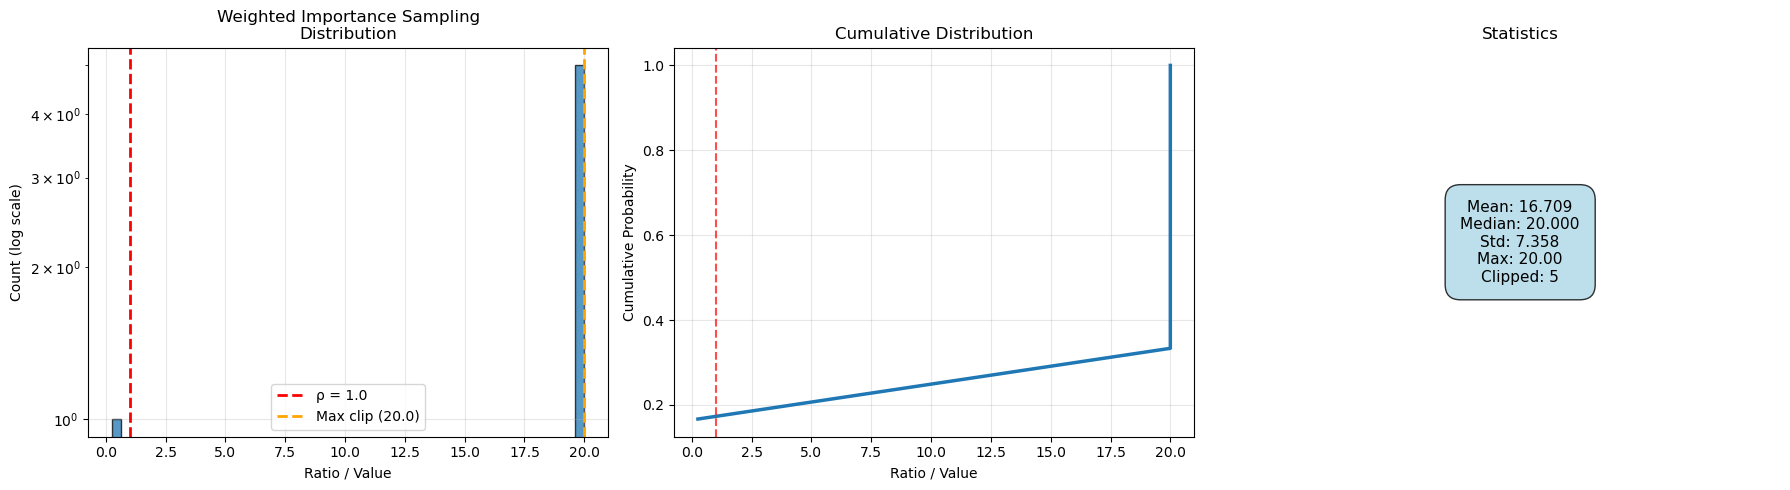

   Saved comparison plot: ope_method_comparison.png


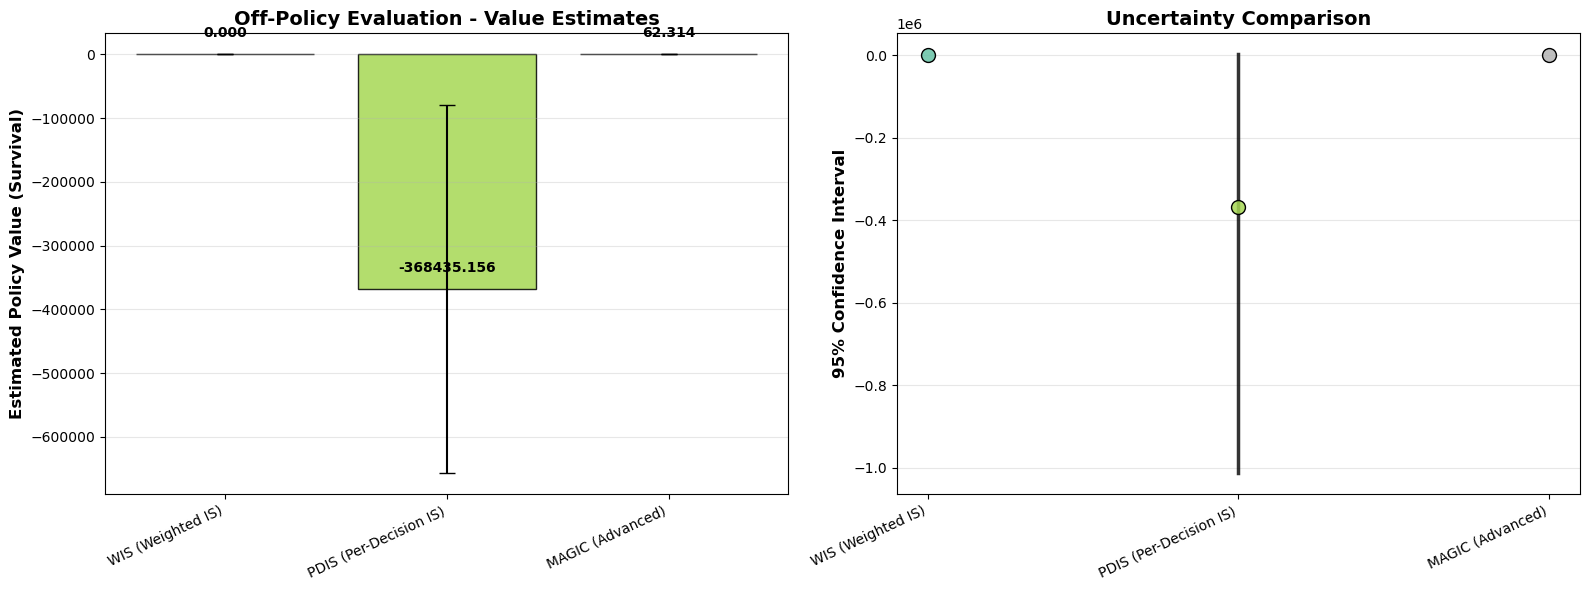

   ✅ Visualizations saved


In [ ]:
# Visualizations
import matplotlib.pyplot as plt
plt.close('all')   # Clear any lingering figures

print("\n[4] Generating visualizations...")

plot_importance_weights(wis_result, save_path='wis_importance_weights.png')
plot_ope_comparison(results_dict, save_path='ope_method_comparison.png')

print("   ✅ Visualizations saved")

In [ ]:
print("Policy Value Estimates (Survival Objective):")
for name, res in results_dict.items():
    print(f"   {name:<30} {res.value:.4f} ± {res.std_error:.4f}   "
            f"CI: [{res.confidence_interval[0]:.4f}, {res.confidence_interval[1]:.4f}]")


Policy Value Estimates (Survival Objective):
   WIS (Weighted IS)              0.0004 ± 0.0002   CI: [-0.0001, 0.0006]
   PDIS (Per-Decision IS)         -368435.1562 ± 288722.8359   CI: [-1013870.4375, 2786.2629]
   MAGIC (Advanced)               62.3136 ± 36.1578   CI: [2.5223, 141.2505]
